# Step 5: Model Development — Finlora Fraud Detection

Trains and validates two classifiers on the engineered feature set: Logistic Regression
(interpretable baseline) and Random Forest (primary prototype). 75/25 stratified split.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
#Imports pandas (already familiar), plus train_test_split — a ready-made function from scikit-learn (stdrd Python ML library) 
# that handles splitting data into training and testing portions, so you don't have to write that logic yourself.


In [2]:
df = pd.read_csv("../data/processed/finlora_model_ready.csv") #Loads the model-ready file saved at FE phase
#... — the one with all 29 numeric/encoded features plus is_fraud.

In [3]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']
#Splits that one dataframe into two classes: X becomes every column except is_fraud 
#... — literally "drop this one column, keep the rest" — this is your feature matrix. 
#... y becomes just the is_fraud column on its own — this is my target/label.

In [4]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Fraud rate:", y.mean()) #Prints the dimensions of each, and recalculates the fraud rate 
#... — purely a sanity check to confirm the reload worked and nothing got corrupted or mismatched.

X shape: (126000, 29)
y shape: (126000,)
Fraud rate: 0.026603174603174604


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)
#This single function call does the actual splitting, and produces four outputs at once (which is why there are four names on the left, all assigned together):
#X_train — 75% of the feature rows, for training
#X_test — 25% of the feature rows, for testing/evaluation
#y_train — the matching fraud labels for the training rows 
#y_test — the matching fraud labels for the test rows

#The three settings we discussed: test_size=0.25 sets the split ratio, 
# stratify=y keeps the fraud rate consistent between the two pieces, 
# random_state=42 makes the random split reproducible every time I re-run it.

print("Train shape:", X_train.shape, "Fraud rate:", y_train.mean())
print("Test shape:", X_test.shape, "Fraud rate:", y_test.mean()) 
#Prints the size of each split and its fraud rate — the check confirming stratification actually worked, 
# i.e. both numbers should sit close to the overall 2.66%.

Train shape: (94500, 29) Fraud rate: 0.026603174603174604
Test shape: (31500, 29) Fraud rate: 0.026603174603174604


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Fit the scaler ONLY on training data, then apply it to both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
#Creates a StandardScaler, fits it on X_train only (learns the mean/std of each feature from training data alone), 
# then applies that same scaling to both X_train and X_test. 
# This puts every feature on a comparable scale, which Logistic Regression's math depends on.

Scaling complete.


In [7]:
logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

print("Model trained.")

#Creates a Logistic Regression model with class_weight='balanced' (compensates for your 2.66% fraud imbalance) 
# and max_iter=1000 (gives it enough optimization steps to converge). 
# .fit(...) is where the actual learning happens — the model looks at X_train_scaled and y_train together 
# and learns the relationship between features and fraud.

Model trained.


## Generating predictions and a first look at performance

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_logreg))
#logreg.predict(...) runs the trained model on the test set (data it's never seen) and outputs a hard 0/1 guess for each transaction. 
# logreg.predict_proba(...) instead outputs the actual fraud probability for each transaction — we take [:, 1] to grab specifically the probability of class 1 (fraud), since predict_proba returns probabilities for both classes side by side. 
# classification_report then prints precision, recall, and F1 for both classes, and roc_auc_score computes the ROC-AUC using the probabilities (not the hard 0/1 predictions, since AUC needs to know how confident the model was, not just its final guess).

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     30662
           1       0.38      0.80      0.52       838

    accuracy                           0.96     31500
   macro avg       0.69      0.88      0.75     31500
weighted avg       0.98      0.96      0.97     31500

ROC-AUC: 0.9345436088204147


Class 0 (legitimate, 30,662 test cases): precision 0.99, recall 0.96 — the model is excellent at correctly identifying legitimate transactions. Expected, since this is the easy majority class.

Class 1 (fraud, 838 test cases) — this is the row that actually matters for your project:

Recall = 0.80 — of all the real fraud cases in the test set, the model correctly caught 80% of them. This is the number your business objective cares about most: "did we catch the bad transactions?"
Precision = 0.38 — of all the transactions the model flagged as fraud, only 38% actually were fraud. The other 62% were legitimate transactions incorrectly flagged (false alarms).
F1 = 0.52 — the balance between those two, pulled down by the weak precision.

Why this exact shape is expected, not a problem: this is precisely the tradeoff class_weight='balanced' produces. You explicitly told the model "missing a fraud case is much more costly than a false alarm," so it leans aggressively toward flagging anything suspicious — catching 80% of real fraud, at the cost of a lot of false positives. In a real analyst review queue, that's often the right tradeoff (a human quickly clears a false alarm; a missed fraud case is actual money lost) — but it does mean this baseline, used alone, would flood analysts with false alarms if deployed as-is.

Why accuracy (0.96) is the wrong headline number here

Notice accuracy sits at 0.96 — looks great in isolation, but remember your baseline "predict nothing is fraud" strategy would already score ~97.3% accuracy while catching zero real fraud. This is exactly why your brief specified precision/recall/F1/ROC-AUC instead of accuracy as the evaluation criteria — accuracy is nearly meaningless on data this imbalanced, and this result proves why.

ROC-AUC = 0.935

This measures how well the model ranks fraud probability overall, independent of any specific decision threshold — it answers "if I pick a random fraud case and a random legitimate case, how often does the model correctly score the fraud case as riskier?" 0.935 is a strong score (1.0 = perfect, 0.5 = random guessing), and importantly, this number reflects the model's underlying discriminative power before any threshold decision — which matters, because your project brief also calls for analyzing "precision at fixed recall operating points (70%, 80%, 90%)" in Step 6. That's the mechanism for adjusting the precision/recall tradeoff you're seeing right now, without retraining the model — just by moving the decision threshold.

This is a genuinely good baseline

A 0.80 recall / 0.935 ROC-AUC Logistic Regression baseline is a strong starting point — exactly what a baseline is for: proving the features carry real signal (which your Step 3 EDA already told us they should) and giving you a number to beat. 

## Random Forest - 300 trees, max depth 10, balanced subsampling

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Model trained.")
#builds a Random Forest of 300 individual decision trees (n_estimators=300), 
# each limited to a depth of 10 splits (max_depth=10, controls overfitting), 
# using balanced_subsample (a per-tree variant of class balancing — each tree gets its own resampled, balanced view of the training data, rather than one fixed global weighting). 
# n_jobs=-1 uses all available CPU cores to train faster, since 300 trees is more computation than a single Logistic Regression. 
# Note: unscaled X_train, not X_train_scaled — tree-based models split on raw feature values and don't need standardization, unlike Logistic Regression.

Model trained.


In [10]:
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf)) 
#rf.predict(X_test) gets hard 0/1 predictions, 
# rf.predict_proba(X_test)[:, 1] gets fraud probabilities, 
# then classification_report and roc_auc_score gives me the same metrics side by side.

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     30662
           1       0.32      0.83      0.46       838

    accuracy                           0.95     31500
   macro avg       0.66      0.89      0.72     31500
weighted avg       0.98      0.95      0.96     31500

ROC-AUC: 0.9335681568643811


Comparing the outcomes Linear Regression and Random Forest

Random Forest edges out Logistic Regression on recall (0.83 vs 0.80 — catches slightly more real fraud), but is actually worse on precision (0.32 vs 0.38 — more false alarms per flagged transaction) and F1 (0.46 vs 0.52). ROC-AUC is essentially a tie (0.9336 vs 0.9345 — a difference this small isn't meaningful).

This is not the outcome the brief implicitly anticipates. Recalling the problem statement's success criteria - "Random Forest (primary model) achieves meaningfully better ROC-AUC / recall-at-precision than the Logistic Regression baseline — otherwise the added complexity isn't justified." Going by this, Random Forest has not earned its place as the "better" model — it's roughly a wash, arguably slightly worse on the metric (F1) that balances both concerns.

## Evaluation

This is the analysis that gives you a fair, apples-to-apples comparison between the two models, rather than judging each at its own arbitrary default threshold.

Confusion matrices and precision-at-fixed-recall analysis for both models, to select the
final model and recommended operating threshold.

In [11]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf)) #a confusion matrix breaks predictions into a 2x2 grid — actual vs. predicted.

Logistic Regression Confusion Matrix:
[[29574  1088]
 [  165   673]]

Random Forest Confusion Matrix:
[[29168  1494]
 [  142   696]]


[[True Negatives,  False Positives]
 [False Negatives, True Positives]]

 True Negatives — correctly identified as legitimate
False Positives — legitimate transactions wrongly flagged as fraud (the "false alarms" behind your precision numbers)
False Negatives — real fraud the model missed entirely (the cases behind recall)
True Positives — real fraud correctly caught

Finding:
Logistic Regression: caught 673 of 838 real fraud cases (165 missed), at the cost of 1,088 false alarms.
Random Forest: caught 696 of 838 real fraud cases (142 missed — 23 more caught than LogReg), at the cost of 1,494 false alarms (406 more than LogReg).

That's the recall/precision tradeoff in concrete terms: Random Forest buys 23 additional caught fraud cases at the cost of 406 additional false alarms. Whether that trade is "worth it" depends entirely on what a false alarm costs an analyst's time versus what a missed fraud case costs the business — exactly the kind of judgment call your precision-at-recall table is built to inform.

In [12]:
from sklearn.metrics import precision_recall_curve
import numpy as np

def precision_at_recall(y_true, y_proba, target_recalls=[0.70, 0.80, 0.90]):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    results = {}
    for target in target_recalls:
        # Find the point on the curve where recall is closest to (but at least) our target
        valid_idx = np.where(recall >= target)[0]
        if len(valid_idx) > 0:
            # Among points meeting the recall target, pick the one with highest precision
            best_idx = valid_idx[np.argmax(precision[valid_idx])]
            results[target] = precision[best_idx]
        else:
            results[target] = None
    return results

print("Logistic Regression — precision at fixed recall:")
print(precision_at_recall(y_test, y_pred_proba_logreg))

print("\nRandom Forest — precision at fixed recall:")
print(precision_at_recall(y_test, y_pred_proba_rf))
#precision at fixed recall -

Logistic Regression — precision at fixed recall:
{0.7: np.float64(0.6464757709251101), 0.8: np.float64(0.3860759493670886), 0.9: np.float64(0.10996213224584911)}

Random Forest — precision at fixed recall:
{0.7: np.float64(0.5465549348230913), 0.8: np.float64(0.3880855986119144), 0.9: np.float64(0.13789954337899543)}


precision_recall_curve computes precision and recall at every possible probability threshold, not just the default 0.5 — this is the tool that finally lets us compare both models fairly, independent of whatever threshold each one happens to default to. The function then answers a specific business question for each target: "if I insist on catching at least 70% (or 80%, or 90%) of real fraud, how precise can I be while hitting that recall level?" This maps directly to the brief's requirement to give the risk team "tunable thresholds depending on review capacity" — a lower recall target generally buys you higher precision (fewer false alarms), while chasing higher recall costs you precision (more false alarms, but catching more real fraud).

Finding:
At 70% recall, Logistic Regression is clearly better (0.646 vs 0.547 precision) — if the risk team wants to catch 7 out of 10 fraud cases, LogReg gives noticeably fewer false alarms per real fraud caught.

At 80% recall, they're essentially tied (0.386 vs 0.388) — a difference this small isn't meaningful.

At 90% recall, Random Forest pulls ahead (0.138 vs 0.110) — if the business wants to catch 9 out of 10 fraud cases (a much more aggressive, "don't miss anything" posture), Random Forest gives meaningfully more usable flags per false alarm, even though both precisions are quite low at this aggressive a recall target.

## Deployment — Streamlit Review Queue

###### This phase os completely different: instead of a notebook I'll run cell-by-cell, app.py is a script that Streamlit runs as a live, interactive web app.

In [13]:
import joblib

# Save the chosen primary model (Logistic Regression) and its scaler together
joblib.dump(logreg, "../model/saved_models/logreg_model.pkl")
joblib.dump(scaler, "../model/saved_models/scaler.pkl")

# Also save Random Forest, in case the business later wants the aggressive-recall option
joblib.dump(rf, "../model/saved_models/rf_model.pkl")

# Save the exact feature column order — critical for Streamlit to build compatible input later
joblib.dump(list(X.columns), "../model/saved_models/feature_columns.pkl")

print("Models saved.")
#joblib is a library built specifically for saving Python objects (like trained models) to disk and loading them back later
#we save 4 things:
#logreg_model.pkl — your chosen primary model
#scaler.pkl — remember, Logistic Regression needs scaled input; Streamlit must scale new transactions the exact same way before predicting, so the scaler itself has to travel with the model
#rf_model.pkl — kept available as the documented alternative for an aggressive-recall policy
#feature_columns.pkl — saves the exact list and order of your 29 feature columns, so when Streamlit builds a prediction input later, it can guarantee the columns line up exactly as the model expects (a mismatch here would silently produce wrong predictions — the same "consistency between train and predict" principle from earlier)

Models saved.


In [14]:
# --- Build a review-ready test set: identifying info + features + true label ---

# Reload the pre-encoding cleaned data to recover human-readable columns
df_readable = pd.read_csv("../data/processed/finlora_cleaned.csv")

# X_test.index holds the original row positions - use them to pull matching readable columns
readable_cols = ['transaction_id', 'account_id', 'timestamp', 'amount', 'merchant_name',
                  'merchant_category', 'channel', 'is_cross_border']
test_review_data = df_readable.loc[X_test.index, readable_cols].copy()

# Attach the model features and true fraud label
test_review_data = pd.concat([test_review_data, X_test.reset_index(drop=True).set_index(test_review_data.index)], axis=1)
test_review_data['is_fraud'] = y_test.values

test_review_data.to_csv("../data/processed/test_review_queue.csv", index=False)
print("Saved:", test_review_data.shape)

Saved: (31500, 38)


In [15]:
print(X_test.shape)
print(y_test.shape) #x_test and y_test checks

(31500, 29)
(31500,)


In [16]:
import sys
print(sys.executable)

c:\Program Files\Python314\python3.14t.exe


## Tweaks

In [18]:
import numpy as np

# --- Logistic Regression: importance from absolute coefficient magnitude ---
logreg_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0],
    'abs_coefficient': np.abs(logreg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

logreg_importance['importance_pct'] = 100 * logreg_importance['abs_coefficient'] / logreg_importance['abs_coefficient'].sum()

print("Logistic Regression - Top 10 Most Important Features:")
print(logreg_importance[['feature', 'coefficient', 'importance_pct']].head(10))

# --- Random Forest: built-in feature_importances_ ---
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

rf_importance['importance_pct'] = 100 * rf_importance['importance']

print("\nRandom Forest - Top 10 Most Important Features:")
print(rf_importance[['feature', 'importance_pct']].head(10))

Logistic Regression - Top 10 Most Important Features:
                               feature  coefficient  importance_pct
0                  amount_to_avg_ratio     5.746029       59.278322
1              transaction_velocity_1h     0.832405        8.587417
17  merchant_category_Payroll Transfer     0.411260        4.242718
23     merchant_category_Wire Transfer     0.410039        4.230128
16      merchant_category_P2P Transfer     0.237518        2.450331
2                        is_new_device     0.218636        2.255540
8              kyc_tier_Tier2_Verified    -0.156592        1.615470
21            merchant_category_Travel     0.153007        1.578486
10   merchant_category_Crypto Exchange     0.149151        1.538702
11       merchant_category_Electronics     0.147835        1.525127

Random Forest - Top 10 Most Important Features:
                                feature  importance_pct
1               transaction_velocity_1h       39.879595
0                   amount_to_avg_rat

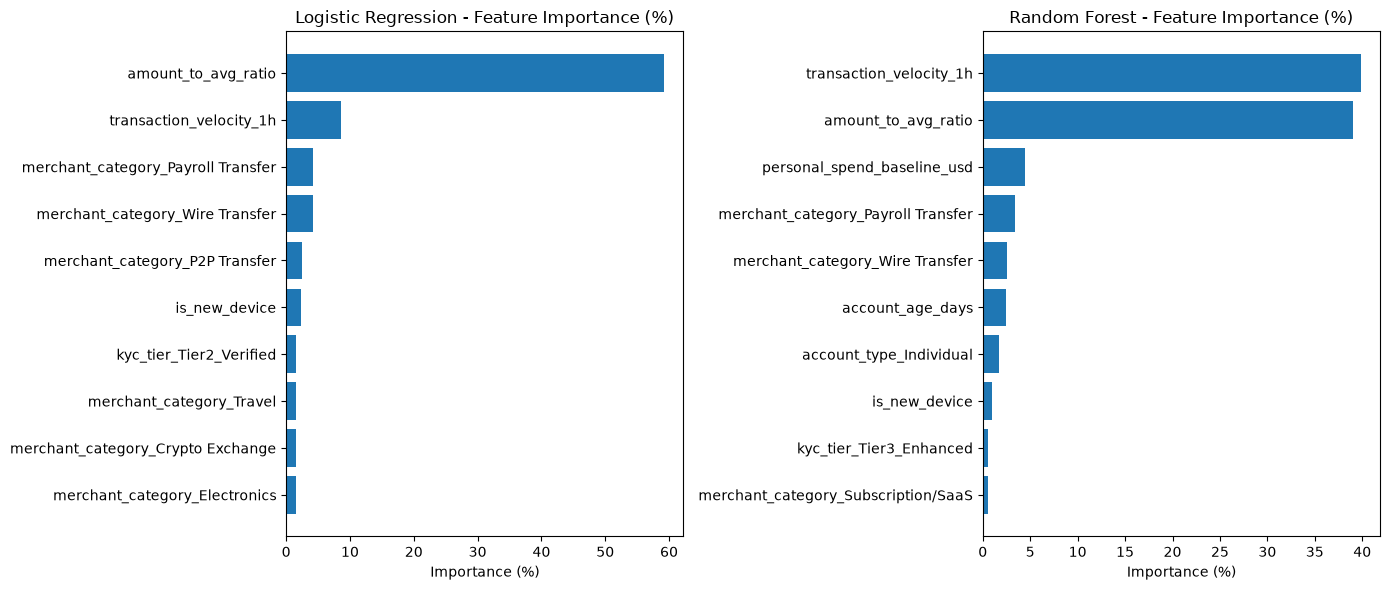

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_logreg = logreg_importance.head(10)
axes[0].barh(top_logreg['feature'], top_logreg['importance_pct'])
axes[0].invert_yaxis()
axes[0].set_title('Logistic Regression - Feature Importance (%)')
axes[0].set_xlabel('Importance (%)')

top_rf = rf_importance.head(10)
axes[1].barh(top_rf['feature'], top_rf['importance_pct'])
axes[1].invert_yaxis()
axes[1].set_title('Random Forest - Feature Importance (%)')
axes[1].set_xlabel('Importance (%)')

plt.tight_layout()
plt.savefig('../docs/feature_importance_chart.png', dpi=150, bbox_inches='tight')
plt.show() 
#two horizontal bar charts side by side, one per model, 
# each showing its own top 10 features ranked by importance percentage. 
# invert_yaxis() puts the most important feature at the top rather than 
# the bottom (horizontal bar charts default to bottom-up order, which reads backwards for a ranking)

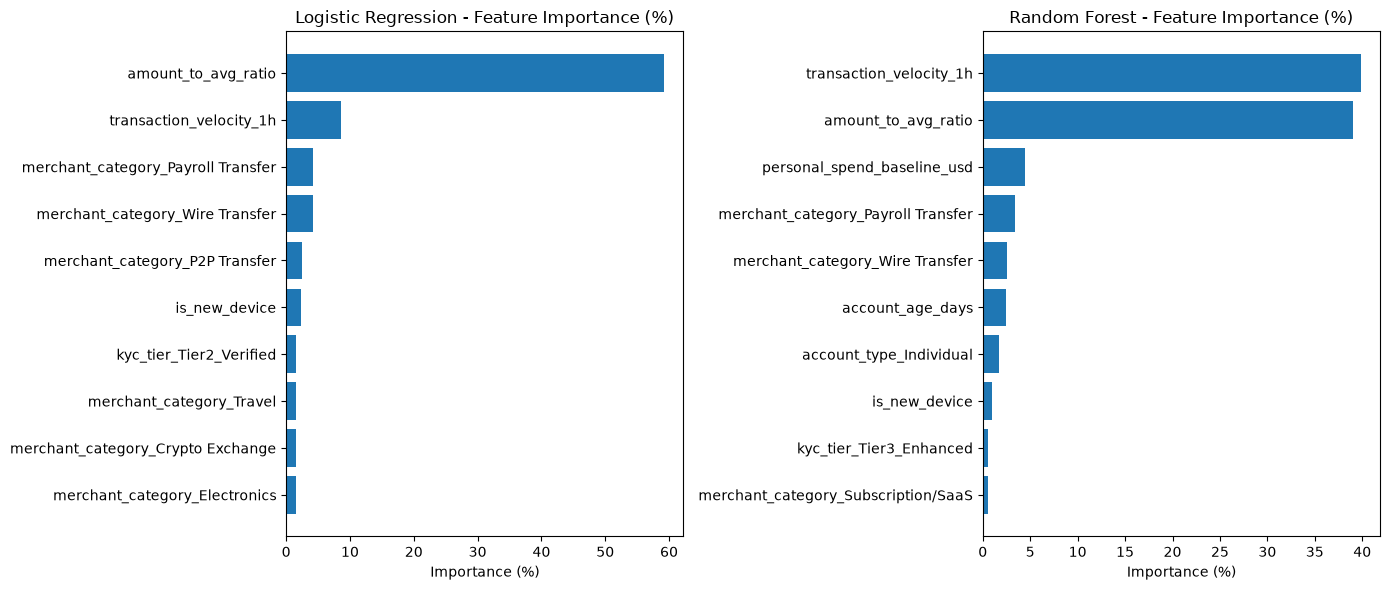

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_logreg = logreg_importance.head(10)
axes[0].barh(top_logreg['feature'], top_logreg['importance_pct'])
axes[0].invert_yaxis()
axes[0].set_title('Logistic Regression - Feature Importance (%)')
axes[0].set_xlabel('Importance (%)')

top_rf = rf_importance.head(10)
axes[1].barh(top_rf['feature'], top_rf['importance_pct'])
axes[1].invert_yaxis()
axes[1].set_title('Random Forest - Feature Importance (%)')
axes[1].set_xlabel('Importance (%)')

plt.tight_layout()
plt.savefig('../docs/feature_importance_chart.png', dpi=150, bbox_inches='tight')
plt.show()